In [1]:
#pip install tensorflow


In [2]:
#pip install pandas numpy matplotlib scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
# 1. Load dữ liệu
df = pd.read_csv("../../data/processed/training_price_final.csv", parse_dates=["Datetime"], index_col="Datetime")

# Chọn cột GOLD để dự đoán
data = df[["Gold"]]

In [5]:
# 2. Tiền xử lí dữ liệu
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [6]:
# 3. Tạo tập dữ liệu huấn luyện và kiểm tra
X, y = [], []
window = 60  # 60 phút trước

for i in range(window, len(scaled_data)):
    X.append(scaled_data[i-window:i, 0])  
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)


In [7]:
# 4.Reshape dữ liệu cho LSTM (3D)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
# Chia train/test theo thời gian
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [8]:
# 5.Xây dựng mô hình LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')


c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# 6. Huấn luyện mô hình
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 182s 43ms/step - loss: 2.4801e-05 - val_loss: 5.4093e-08
Epoch 2/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 206s 44ms/step - loss: 1.8589e-06 - val_loss: 6.2773e-09
Epoch 3/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 212s 47ms/step - loss: 1.4827e-06 - val_loss: 4.1648e-07
Epoch 4/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 198s 46ms/step - loss: 1.1809e-06 - val_loss: 1.3770e-08
Epoch 5/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 195s 44ms/step - loss: 9.7498e-07 - val_loss: 1.6096e-07
Epoch 6/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 182s 45ms/step - loss: 7.9280e-07 - val_loss: 2.1199e-08
Epoch 7/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 175s 44ms/step - loss: 6.5346e-07 - val_loss: 2.6690e-09
Epoch 8/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 202s 44ms/step - loss: 6.8139e-07 - val_loss: 4.4001e-08
Epoch 9/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 204s 44ms/step - loss: 6.3028e-07 - val_loss: 9.0792e-08
Epoch 10/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 181s 45ms/step - loss: 5.8367e-07 - val_loss: 4.4645e-09
Epoch 11/

In [23]:
print(f"🔍 Max giá trong scaler gốc: {scaler.data_max_}")

🔍 Max giá trong scaler gốc: [4362.47]


In [ ]:
# 7. Dự đoán
y_pred_scaled = model.predict(X_test)

# Chuyển từ [0,1] về giá thật
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_real = scaler.inversSe_transform(y_test.reshape(-1, 1))


1112/1112 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step


In [18]:
# 8. Đánh giá mô hình
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print("RMSE:", rmse)
print("R² score:", r2)


RMSE: 1.2200291160114165
R² score: 0.9995815487069041


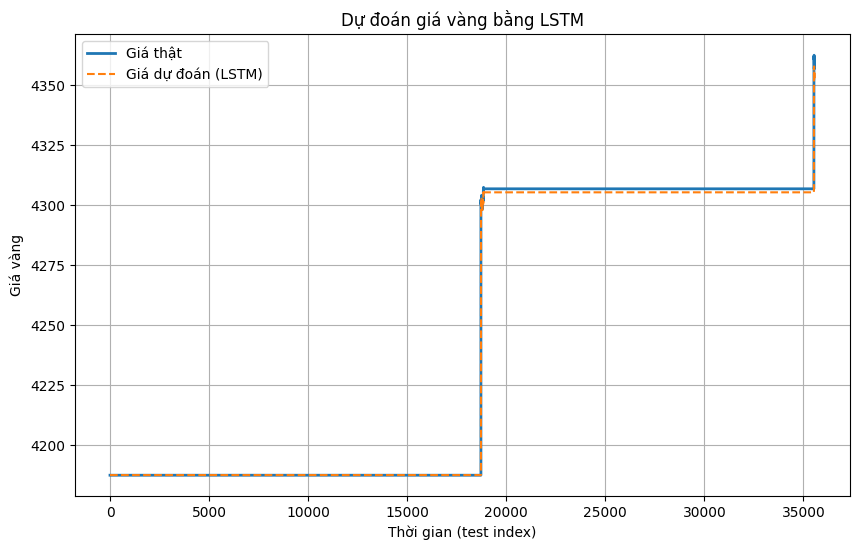

In [19]:
# 9. Vẽ biểu đồ dự đoán
plt.figure(figsize=(10,6))
plt.plot(y_test_real, label="Giá thật", linewidth=2)
plt.plot(y_pred, label="Giá dự đoán (LSTM)", linestyle='--')
plt.title("Dự đoán giá vàng bằng LSTM")
plt.xlabel("Thời gian (test index)")
plt.ylabel("Giá vàng")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
# 4. Xử lý thời gian (Fix lỗi AttributeError bạn gặp lúc nãy)
# Lấy n dòng cuối cùng của index gốc, với n = số lượng mẫu dự đoán
test_dates = df.index[-len(y_test_real):]

# 5. Tạo DataFrame
result_df = pd.DataFrame({
    'Datetime': test_dates,
    'Actual': y_test_real.flatten(),
    'Predicted': y_pred.flatten()
})

# 6. Lưu file CSV
import os
save_path = '../../results/predictions/LSTM.csv'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
result_df.to_csv(save_path, index=False)

print(f"✅ Đã lưu kết quả LSTM (USD) vào: {save_path}")
print(result_df.tail())

✅ Đã lưu kết quả LSTM (USD) vào: ../../results/predictions/LSTM.csv
                 Datetime   Actual    Predicted
35556 2025-12-18 23:57:00  4357.14  4353.111816
35557 2025-12-18 23:57:10  4358.14  4352.827148
35558 2025-12-18 23:57:20  4359.20  4353.773438
35559 2025-12-18 23:57:30  4359.63  4354.728516
35560 2025-12-18 23:57:40  4359.63  4355.104980
